In [105]:
from thinkbayes import Suite, Pmf
from train import Train
import numpy as np

class Train2(Suite):

    def __init__(self, hypos, alpha=1.0):
        #super().__init__(hypos)
        Pmf.__init__(self)
        for hypo in hypos:
            self.Set(hypo, hypo**(-alpha))
        self.Normalize()

    def Likelihood(self, data, hypo):
        if hypo < data:
            return 0
        else:
            return 1.0/hypo   

In [106]:
for r in [500, 1000, 2000]:
    hypos = range(1,r+1)
    suite = Train2(hypos)

    for data in [30,60,90]:
        suite.Update(data)

    print(f'{r} : {suite.Mean():.0f}')
    hypos = np.array([h for h, p in suite.Items()])
    probs = np.array([p for h, p in suite.Items()])

    cdf = np.cumsum(probs)

    ci = hypos[np.searchsorted(cdf, [0.05, 0.95])]
    print(ci)
    


500 : 131
[ 91 235]
1000 : 133
[ 91 242]
2000 : 134
[ 91 243]


In [107]:
hypos = range(1,1001)
suite = Train2(hypos)

suite.Update(60)

post = [v for k, v in suite.Items()]



In [108]:
suite2 = Train(hypos)
suite2.Update(60)

post2 = [v for k, v in suite2.Items()]

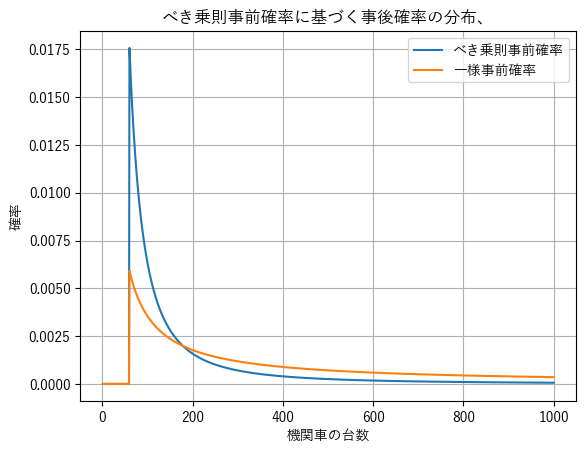

In [109]:
import matplotlib.pyplot as plt
import japanize_matplotlib

plt.plot(hypos, post, label="べき乗則事前確率")
plt.plot(hypos, post2, label="一様事前確率")
plt.xlabel('機関車の台数')
plt.ylabel('確率')

plt.title('べき乗則事前確率に基づく事後確率の分布、')
plt.legend()
plt.grid(True)

In [110]:
plt.rcParams['font.family'] = 'YuGothic'

In [116]:
import numpy as np

hypos = np.array([h for h, p in suite.Items()])
probs = np.array([p for h, p in suite.Items()])

cdf = np.cumsum(probs)

ci = hypos[np.searchsorted(cdf, [0.05, 0.95])]
print(ci)

[ 62 559]


In [117]:
cdf = suite.MakeCdf()
cdf.Percentile(5)


62